# **Pregunta I**
Considerando el archivo dataset_sensores.csv, que contiene 3.000 observaciones de un sistema de medición con 10 variables de entrada (sensor1, sensor2, noise1-noise8) y una variable objetivo-binaria, que indica si ocurrió (1) o no (0) un evento de interés.



### **Pregunta A** ###

Lea y separe los datos en muestra de entrenamiento, validación y prueba (por ejemplo, 60% / 20% / 20%, dejando constancia de cómo lo hizo). Aplique estandarización de las variables de entradas (por ejemplo, StandardScaler u otro método equivalente), ajustando el escalador solo con el conjunto de entrenamiento y luego aplicándolo a validación y prueba.

In [2]:
# Importar la Librerias necesarias
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report, RocCurveDisplay)

from sklearn.linear_model import LogisticRegression

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping

SEMILLA = 124
np.random.seed(SEMILLA)
tf.random.set_seed(SEMILLA)

In [4]:
# Importar dataset
df = pd.read_csv('dataset_sensores.csv')

df.head()

,sensor1,sensor2,noise1,noise2,noise3,noise4,noise5,noise6,noise7,noise8,target
0,-0.989121,0.208939,0.557609,-0.616261,-1.485264,-0.326323,-0.969005,0.637658,0.180368,-0.883388,1
1,-0.367787,-0.623170,-0.035013,0.279594,0.833989,-0.842990,-0.474100,-0.243262,-0.446569,0.431656,1
2,1.287925,0.410138,0.202057,1.667634,-1.314656,-1.203411,0.118244,-1.125350,1.175253,-1.348657,1
3,0.193974,1.650235,0.312437,-1.522121,0.224403,-2.322448,1.901773,0.368404,0.181723,1.693803,1
4,0.920231,-1.240805,-1.281850,-1.162017,1.562077,1.879348,-1.014581,-1.421919,0.967803,0.807129,1


In [7]:
# Separar la variable objetivo
X = df.drop('target', axis = 1)
Y = df['target']

# Proporción de casos 'target'
Y.value_counts()

,count
target,
0,1517
1,1483


In [9]:
# Data de entrenamiento, validación y prueba (60/20/20)

# Entrenamiento (60%) y temporal (40%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, Y, test_size=0.4, random_state=42, stratify=Y)

# Data Temporal: Validación (20%) y Prueba (20%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

# Verificar tamaños
print(f'Train: {X_train.shape}, Validation: {X_val.shape}, Test: {X_test.shape}')

Train: (1800, 10), Validation: (600, 10), Test: (600, 10)


In [10]:
# Estandarizar las variables de entrada
scaler = StandardScaler().fit(X_train)

# Tranformar los conjutos
X_train_std = scaler.transform(X_train)
X_val_std = scaler.transform(X_val)
X_test_std = scaler.transform(X_test)

### **Pregunta B** ###
Entrene un modelo de Machine Learning clásico de su elección para clasificar la variable taret (puede ser, por ejemplo: Regresión Logística, Random Forest, SVM, u otro clasificador razonable). Reporte sus métricas de evaluación en el conjunto de prueba (por ejemplo: accuracy y matriz de confusionismos; asi lo desea, puede agregar AUC, F1 u otras).


In [24]:
# Modelo de Regresión Logística

# Entrenar el modelo
lr = LogisticRegression(max_iter = 1000, random_state = SEMILLA)
lr.fit(X_train, y_train)

# Predicciones
y_test_pred = lr.predict(X_test_std)
y_test_proba = lr.predict_proba(X_test_std)[:, 1]

# Métricas de evaluación
acc  = accuracy_score(y_test, y_test_pred)
prec = precision_score(y_test, y_test_pred)
rec  = recall_score(y_test, y_test_pred)
f1   = f1_score(y_test, y_test_pred)
auc  = roc_auc_score(y_test, y_test_proba)
conf = confusion_matrix(y_test, y_test_pred)

print("=== Métricas en Test (Regresión Logística) ===")
print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1:        {f1:.4f}")
print(f"AUC:       {auc:.4f}")

print("\n=== Matríz de Confusión ===")
print(f'{conf}')

print("\n=== Reporte de clasificación ===")
print(classification_report(y_test, y_test_pred, digits=4))



=== Métricas en Test (Regresión Logística) ===
Accuracy:  0.5300
Precision: 0.5254
Recall:    0.4899
F1:        0.5070
AUC:       0.5167

=== Matríz de Confusión ===
[[173 131]
 [151 145]]

=== Reporte de clasificación ===
              precision    recall  f1-score   support

           0     0.5340    0.5691    0.5510       304
           1     0.5254    0.4899    0.5070       296

    accuracy                         0.5300       600
   macro avg     0.5297    0.5295    0.5290       600
weighted avg     0.5297    0.5300    0.5293       600



/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [32]:
# Entrenar el Modelo Random Forest
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators = 100, random_state = SEMILLA)
rf.fit(X_train_std, y_train)

# Predicciones
y_pred_rf = rf.predict(X_test_std)
y_proba_rf = rf.predict_proba(X_test_std)[:,1]

# Métricas
acc  = accuracy_score(y_test, y_pred_rf)
prec = precision_score(y_test, y_pred_rf)
rec  = recall_score(y_test, y_pred_rf)
f1   = f1_score(y_test, y_pred_rf)
auc  = roc_auc_score(y_test, y_proba_rf)
conf = confusion_matrix(y_test, y_pred_rf)

print("=== Métricas en Test (Random Forest) ===")
print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1:        {f1:.4f}")
print(f"AUC:       {auc:.4f}")

print("\n=== Matríz de Confusión ===")
print(f'{conf}')

print("\n=== Reporte de clasificación ===")
print(classification_report(y_test, y_pred_rf, digits=4))

=== Métricas en Test (Random Forest) ===
Accuracy:  0.8567
Precision: 0.8477
Recall:    0.8649
F1:        0.8562
AUC:       0.8931

=== Matríz de Confusión ===
[[258  46]
 [ 40 256]]

=== Reporte de clasificación ===
              precision    recall  f1-score   support

           0     0.8658    0.8487    0.8571       304
           1     0.8477    0.8649    0.8562       296

    accuracy                         0.8567       600
   macro avg     0.8567    0.8568    0.8567       600
weighted avg     0.8568    0.8567    0.8567       600



## **Pregunta C** ##
Entrene ahora una red neuronal MLP para el mismo problema de clasificación binaria, cumpliendo con: (i) Una capa de entrada con las 10 variables explicativas, (ii) Dos capas ocultas (intermedias) con función de activación ReLU y (iii) una capa de salida apropiada para clasificación binaria.

El resto de los hiperparámetros (número de neuronas por capa, tasa de aprendizaje, numero de épocas, batch size, etc.) quedan a su elección; no es necesario realizar búsqueda exhaustiva ni grilla de hiperparámetros.

Reporte las métricas de evaluación en el conjunto de prueba, de manera análoga al modelo clásico (accuracy, matriz de confusionismos, etc).

Compare breve (en 2-3 líneas) el desempeño de la red neuronal versus el modelo clásico.


In [28]:
# Modelo de Red Neuronal

# Definir el modelo MLP
model = keras.Sequential([
    layers.Dense(32, activation='relu', input_shape=(X_train_std.shape[1],)), # Corrected: Use X_train_std.shape[1] for the number of features
    layers.Dense(16, activation='relu'),
    layers.Dense(1, activation='sigmoid')])

# Compilar el modelo
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy", keras.metrics.AUC(name="auc")])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 32)             │           352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 897 (3.50 KB)

 Trainable params: 897 (3.50 KB)

 Non-trainable params: 0 (0.00 B)

In [29]:
# Entrenamiento con EarlyStopping
es = keras.callbacks.EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)
history = model.fit(
    X_train_std, y_train,
    validation_data=(X_val_std, y_val),
    epochs=500,
    batch_size=124,
    callbacks=[es],
    verbose=1
)

Epoch 1/500
15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - accuracy: 0.5084 - auc: 0.5020 - loss: 0.7023 - val_accuracy: 0.5617 - val_auc: 0.5618 - val_loss: 0.6898
Epoch 2/500
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.5469 - auc: 0.5640 - loss: 0.6889 - val_accuracy: 0.5833 - val_auc: 0.5976 - val_loss: 0.6817
Epoch 3/500
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.5831 - auc: 0.6105 - loss: 0.6794 - val_accuracy: 0.5883 - val_auc: 0.6291 - val_loss: 0.6740
Epoch 4/500
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.6158 - auc: 0.6475 - loss: 0.6705 - val_accuracy: 0.5967 - val_auc: 0.6565 - val_loss: 0.6657
Epoch 5/500
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6390 - auc: 0.6811 - loss: 0.6610 - val_accuracy: 0.6150 - val_auc: 0.6847 - val_loss: 0.6561
Epoch 6/500
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6652 - auc: 0.7132 - loss: 0.6501 - val_accuracy: 0.6500 - val_auc: 0.7135 - val_loss: 0.6450
Epoch 7/500
15/15 ━━━━━━━━━━━━━━━━━━━━ 0

In [30]:
loss_test, acc_test, auc_test = model.evaluate(X_test_std, y_test, verbose=0)
print("\n=== Evaluación Keras (test) ===")
print(f"loss: {loss_test:.4f} | acc: {acc_test:.4f} | auc: {auc_test:.4f}")


=== Evaluación Keras (test) ===
loss: 0.4705 | acc: 0.8083 | auc: 0.8799


In [35]:
# Métricas del modelo MLP
y_pred_mlp_proba = model.predict(X_test_std, verbose=0).ravel()
y_pred_mlp = (y_pred_mlp_proba >= 0.5).astype(int)

acc  = accuracy_score(y_test, y_pred_mlp)
prec = precision_score(y_test, y_pred_mlp)
rec  = recall_score(y_test, y_pred_mlp)
f1   = f1_score(y_test, y_pred_mlp)
auc  = roc_auc_score(y_test, y_pred_mlp_proba)

print("\n=== Métricas adicionales (test) ===")
print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1:        {f1:.4f}")
print(f"AUC:       {auc:.4f}")

# Matriz de confusión y reporte de clasificación
print("\n=== Matriz de Confusión (test) ===")
print(confusion_matrix(y_test, y_pred_mlp))

print("\n=== Reporte de Clasificación (test) ===")
print(classification_report(y_test, y_pred_mlp, digits=4))


=== Métricas adicionales (test) ===
Accuracy:  0.8083
Precision: 0.7891
Recall:    0.8345
F1:        0.8112
AUC:       0.8800

=== Matriz de Confusión (test) ===
[[238  66]
 [ 49 247]]

=== Reporte de Clasificación (test) ===
              precision    recall  f1-score   support

           0     0.8293    0.7829    0.8054       304
           1     0.7891    0.8345    0.8112       296

    accuracy                         0.8083       600
   macro avg     0.8092    0.8087    0.8083       600
weighted avg     0.8095    0.8083    0.8083       600



In [39]:
# Predicciones REGRESION LOGISTICA
y_test_pred = lr.predict(X_test_std)
y_test_proba = lr.predict_proba(X_test_std)[:, 1]

# Predicciones RANDOM FOREST
y_pred_rf = rf.predict(X_test_std)
y_proba_rf = rf.predict_proba(X_test_std)[:,1]

# Predicciones RED REURONAL
y_pred_mlp_proba = model.predict(X_test_std, verbose=0).ravel()
y_pred_mlp = (y_pred_mlp_proba >= 0.5).astype(int)

# Métricas
metrics = {}
for name, y_pred, y_proba in [
    ('Regresión Logística', y_test_pred, y_test_pred),
    ('Random Forest', y_pred_rf, y_proba_rf),
    ('Red Neuronal', y_pred_mlp, y_pred_mlp_proba)
]:
    metrics[name] = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1': f1_score(y_test, y_pred),
        'AUC': roc_auc_score(y_test, y_proba)
    }

print(metrics)



{'Regresión Logística': {'Accuracy': 0.53, 'Precision': 0.5253623188405797, 'Recall': 0.48986486486486486, 'F1': 0.506993006993007, 'AUC': np.float64(0.5167363086770982)}, 'Random Forest': {'Accuracy': 0.8566666666666667, 'Precision': 0.847682119205298, 'Recall': 0.8648648648648649, 'F1': 0.8561872909698997, 'AUC': np.float64(0.8931143314366999)}, 'Red Neuronal': {'Accuracy': 0.8083333333333333, 'Precision': 0.7891373801916933, 'Recall': 0.8344594594594594, 'F1': 0.8111658456486043, 'AUC': np.float64(0.8799564366998577)}}


In [45]:
# Curva ROC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve

fpr_lr, tpr_lr, _ = roc_curve(y_test, y_test_pred)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)
fpr_mlp, tpr_mlp, _ = roc_curve(y_test, y_pred_mlp_proba)

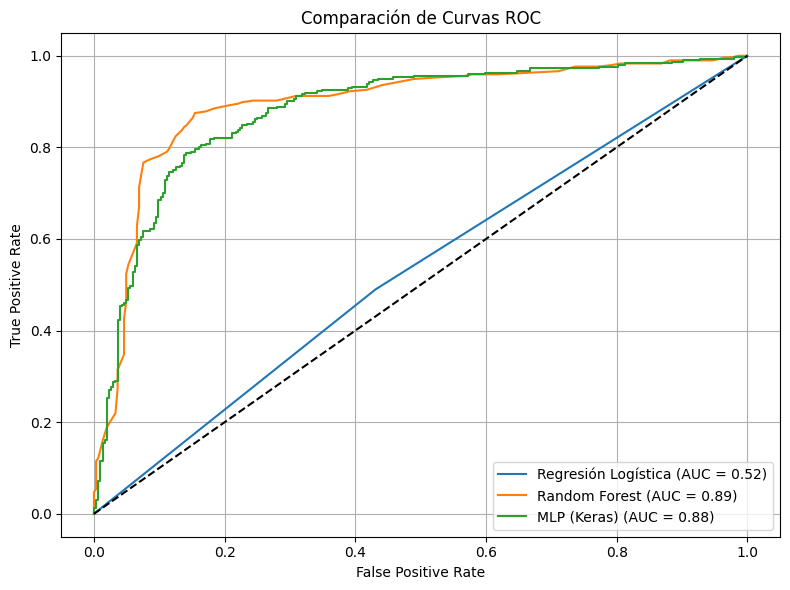

In [46]:
# 10. Graficar curvas ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr_lr, tpr_lr, label=f"Regresión Logística (AUC = {metrics['Regresión Logística']['AUC']:.2f})")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {metrics['Random Forest']['AUC']:.2f})")
plt.plot(fpr_mlp, tpr_mlp, label=f"MLP (Keras) (AUC = {metrics['Red Neuronal']['AUC']:.2f})")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Comparación de Curvas ROC")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()

## **PREGUNTA D** ##
Genere el pronóstico, usando la red neuronal, de la variable target para cada observación del archivo predict_sensores.csv y reporte cuantas fallas encuentra.

In [47]:
# Cargar dataset
predict_df = pd.read_csv('predict_sensores.csv')

predict_df.head()

,sensor1,sensor2,noise1,noise2,noise3,noise4,noise5,noise6,noise7,noise8
0,0.896040,1.172377,-0.138708,-0.968773,0.681022,1.200568,-0.432308,0.641424,1.528782,-0.233098
1,-2.123949,0.068681,-0.236848,0.158286,1.790371,-0.941516,-0.129430,-0.703246,0.343755,1.017703
2,1.640204,-0.806608,0.399302,-1.164659,0.270042,-0.172383,-0.303618,-0.502360,-0.312711,-2.233537
3,-0.035307,0.135437,0.965891,0.506428,-0.489020,-0.277953,-0.359084,0.769461,0.488250,0.593075
4,-2.602765,-0.923161,0.071780,-0.357477,-0.026260,1.433086,0.137854,0.155194,-0.396684,-0.758428


In [48]:
# Estandarizar los datos de predicción
predict_std = scaler.transform(predict_df)

In [53]:
# Realizar las predicciones
pred_proba = model.predict(predict_std, verbose=0).ravel()
pred_labels = (pred_proba >=0.5).astype(int)

In [54]:
# Contar número de fallas (target = 1)
num_fallas = int(pred_labels.sum())
print(f"Número de observaciones clasificadas como 1 (falla): {num_fallas}")

Número de observaciones clasificadas como 1 (falla): 16
